In [5]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import os

# =====================================================
# Paths
# =====================================================
base='../data/2018_08_25'

mag_path = os.path.join(base,"cubes/MAG_24.fits")

geometry_path = os.path.join(base,"supergranule_masks_geometry.npz")


# =====================================================
# Load magnetogram cube
# =====================================================
hdul = fits.open(
    mag_path,
    memmap=True,
    do_not_scale_image_data=True
)

mag_cube_raw = hdul[0].data
mag_header = hdul[0].header

print("Cube shape:", mag_cube_raw.shape)
print("Raw dtype:", mag_cube_raw.dtype)

bscale = mag_header.get("BSCALE", 1.0)
bzero = mag_header.get("BZERO", 0.0)

print("BSCALE:", bscale)
print("BZERO:", bzero)

# =====================================================
# Load supergranule geometry
# =====================================================

geometry = np.load(
    geometry_path
)

centers_x = geometry["x"]
centers_y = geometry["y"]
radii = geometry["radius"]

print("Number of supergranules:", len(radii))

Cube shape: (1920, 1024, 1024)
Raw dtype: >i8
BSCALE: 1e-16
BZERO: 0.0
Number of supergranules: 44


Spatial scale X: 0.348 Mm/pixel
Spatial scale Y: 0.348 Mm/pixel


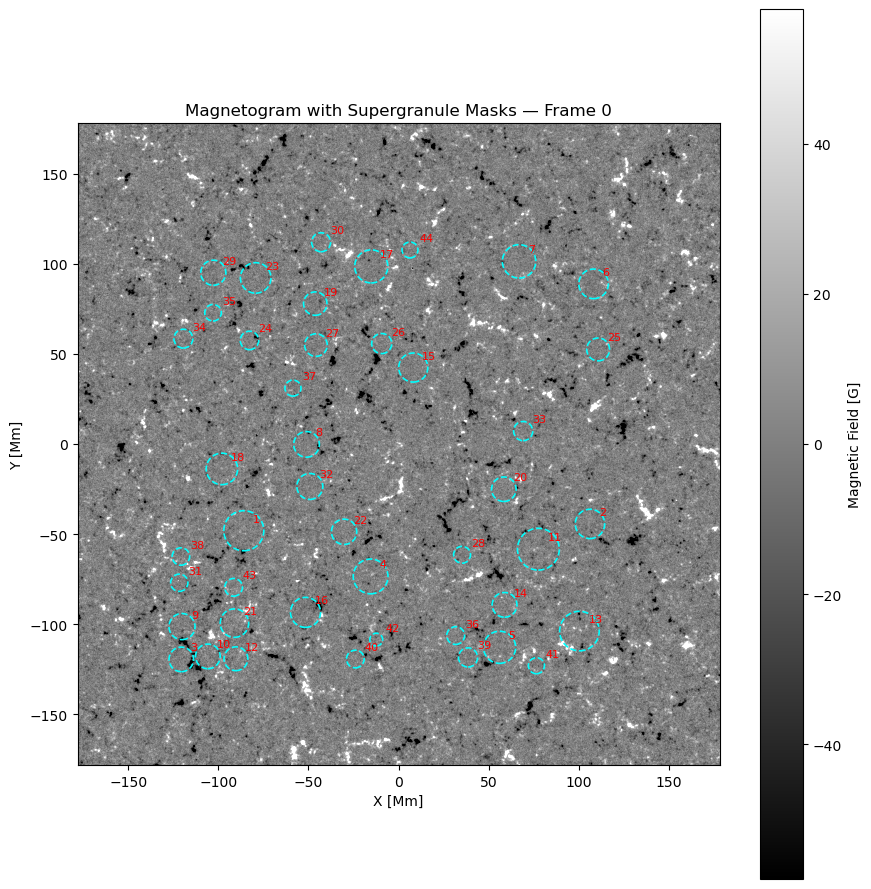

In [8]:
# =====================================================
# Inspect one magnetogram frame with supergranule masks
# Physical coordinates in Mm
# =====================================================

frame_id = 0

# -----------------------------------------------------
# Load and scale only the selected frame
# -----------------------------------------------------

frame = (
    mag_cube_raw[frame_id].astype(np.float64) * bscale
    + bzero
)

# Symmetric magnetic-field scale around zero
limit = np.nanpercentile(
    np.abs(frame),
    99
)


# -----------------------------------------------------
# Spatial scale: pixel -> Mm
# -----------------------------------------------------

# =====================================================
# Spatial scale of the Postel map
# =====================================================

rsun = 696.0  # Solar radius [Mm]

daxis1 = mag_header["DAXIS1"]  # rad / pixel
daxis2 = mag_header["DAXIS2"]  # rad / pixel

scale_x = daxis1 * rsun  # Mm / pixel
scale_y = daxis2 * rsun  # Mm / pixel

print(f"Spatial scale X: {scale_x:.3f} Mm/pixel")
print(f"Spatial scale Y: {scale_y:.3f} Mm/pixel")


# -----------------------------------------------------
# Image extent in physical coordinates
# -----------------------------------------------------

ny, nx = frame.shape

x0 = mag_header["X0"]
y0 = mag_header["Y0"]

extent = [
    (0 - x0) * scale_x,
    (nx - x0) * scale_x,
    (0 - y0) * scale_y,
    (ny - y0) * scale_y
]


# -----------------------------------------------------
# Plot magnetogram
# -----------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 9))

im = ax.imshow(
    frame,
    origin="lower",
    cmap="gray",
    vmin=-limit,
    vmax=limit,
    extent=extent
)


# -----------------------------------------------------
# Overlay supergranule masks
# -----------------------------------------------------

for sg_id, (cx, cy, radius) in enumerate(
    zip(centers_x, centers_y, radii),
    start=1
):

    # Convert geometry from pixels to Mm
    cx_mm = (cx - x0) * scale_x
    cy_mm = (cy - y0) * scale_y
    radius_mm = radius * scale_x

    circle = plt.Circle(
        (cx_mm, cy_mm),
        radius_mm,
        fill=False,
        linestyle="--",
        linewidth=1.2,
        color="cyan"
    )

    ax.add_patch(circle)

    # Supergranule ID
    ax.text(
        cx_mm + 5,
        cy_mm + 5,
        str(sg_id),
        fontsize=8,
        color="red"
    )


# -----------------------------------------------------
# Labels and colorbar
# -----------------------------------------------------

ax.set_title(
    f"Magnetogram with Supergranule Masks — Frame {frame_id}"
)

ax.set_xlabel("X [Mm]")
ax.set_ylabel("Y [Mm]")

fig.colorbar(
    im,
    ax=ax,
    label="Magnetic Field [G]"
)

fig.tight_layout()

plt.show()